In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib의 핵심 모듈
import seaborn as sns              # 통계 시각화 라이브러리
import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 숨김

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'        # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False          # 마이너스 부호 깨짐 방지
plt.rcParams['figure.figsize'] = (10, 6)            # 기본 그래프 크기
plt.rcParams['figure.dpi'] = 100                    # 해상도

# Jupyter 노트북에서 그래프 인라인 표시
%matplotlib inline

print("라이브러리 로드 완료!")
print(f"matplotlib 버전: {plt.matplotlib.__version__}")
print(f"seaborn 버전: {sns.__version__}")

라이브러리 로드 완료!
matplotlib 버전: 3.8.3
seaborn 버전: 0.13.2


In [2]:
# 데이터 로드 (이번 수업에서 사용할 7개 데이터셋)
# 1) 컴퓨터 가격 데이터
df_comp = pd.read_csv('pandas/data/computer_prices_all.csv')

# 2) 상하수도 요금 데이터
df_water = pd.read_csv('pandas/data/경상북도 안동시_상하수도요금정보_20251124.csv', encoding='cp949')

# 3) Spotify 2023 인기곡
df_spotify = pd.read_csv('pandas/data/spotify-2023.csv', encoding='latin-1')

# 4) 타이타닉 생존 데이터
df_titanic = pd.read_csv('pandas/data/titanic_train.csv')

# 5) 국세청 사업자현황
df_biz = pd.read_csv('pandas/data/국세청_사업자현황_성별_20240930.csv', encoding='cp949')

# 6) 서울 지하철 혼잡도
df_subway = pd.read_csv('pandas/data/서울교통공사_ 혼잡도_20171231.csv', encoding='cp949')

# 7) 캘리포니아 주택 가격
df_housing = pd.read_csv('pandas/data/california_housing_test.csv')

print("=== 데이터 로드 완료 ===")
for name, df in [('컴퓨터 가격', df_comp), ('상하수도 요금', df_water), ('Spotify', df_spotify),
                  ('타이타닉', df_titanic), ('사업자현황', df_biz), ('지하철 혼잡도', df_subway),
                  ('주택 가격', df_housing)]:
    print(f"  {name}: {df.shape[0]:>8,}행 × {df.shape[1]}열")

=== 데이터 로드 완료 ===
  컴퓨터 가격:  100,000행 × 33열
  상하수도 요금:  471,984행 × 6열
  Spotify:      953행 × 24열
  타이타닉:      891행 × 8열
  사업자현황:    8,527행 × 13열
  지하철 혼잡도:    1,668행 × 44열
  주택 가격:    3,000행 × 9열


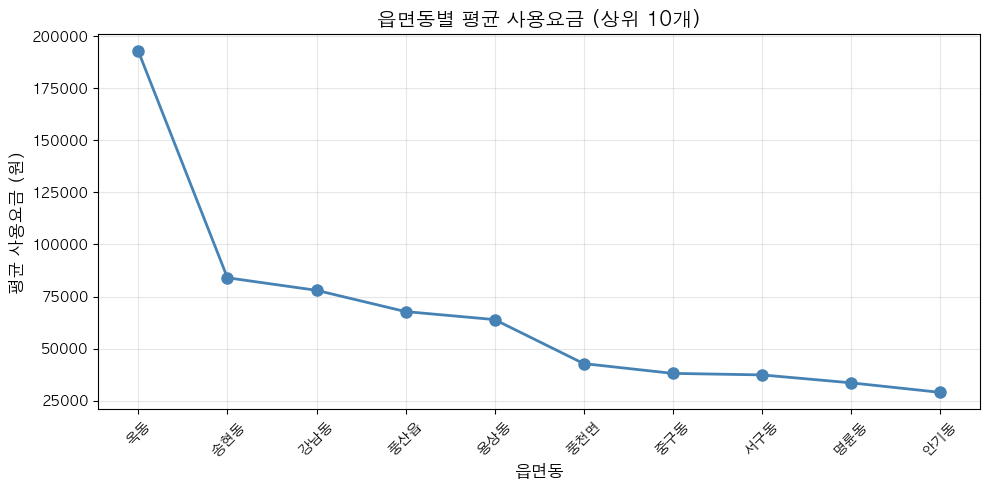

In [3]:
# 가장 기본적인 선 그래프 (Line Plot)
# 상하수도 데이터: 읍면동별 평균 사용요금

# 데이터 준비 - 읍면동별 평균 요금 (상위 10개 지역)
dong_avg = df_water.groupby('읍면동명')['사용요금'].mean().sort_values(ascending=False).head(10)

# plt 방식 - 빠르고 간편한 시각화
plt.figure(figsize=(10, 5))                          # 그래프 크기 설정
plt.plot(dong_avg.index, dong_avg.values,            # x축: 읍면동명, y축: 평균요금
         marker='o',                                  # 데이터 포인트 마커
         color='steelblue',                           # 선 색상
         linewidth=2,                                 # 선 두께
         markersize=8)                                # 마커 크기

plt.title('읍면동별 평균 사용요금 (상위 10개)', fontsize=14, fontweight='bold')  # 제목
plt.xlabel('읍면동', fontsize=12)                     # x축 라벨
plt.ylabel('평균 사용요금 (원)', fontsize=12)          # y축 라벨
plt.xticks(rotation=45)                               # x축 라벨 회전
plt.grid(True, alpha=0.3)                             # 격자선 (투명도 0.3)
plt.tight_layout()                                    # 레이아웃 자동 조정
plt.show()


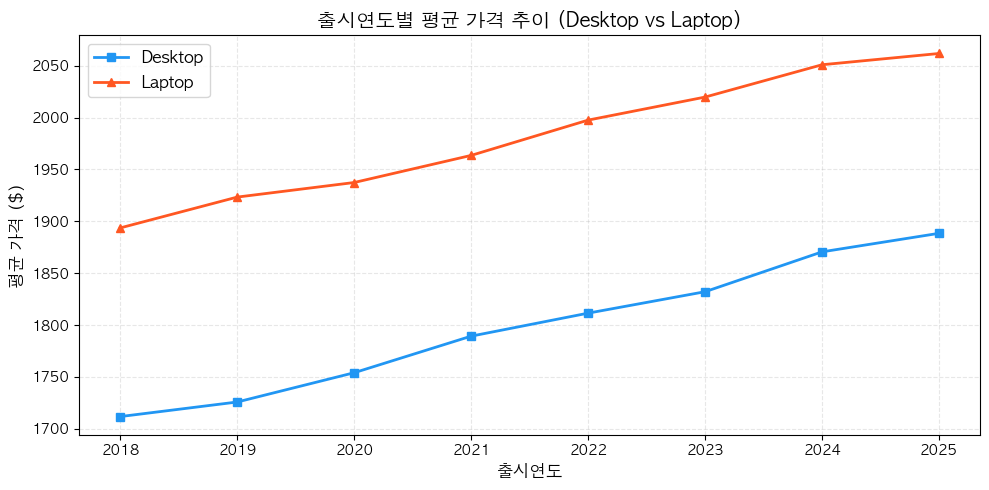

In [4]:
# 여러 선을 하나의 그래프에 그리기 + 범례(legend)
# 컴퓨터 데이터: 출시연도별 Desktop vs Laptop 평균 가격 추이

# 데이터 준비
yearly_price = df_comp.groupby(['release_year', 'device_type'])['price'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))              # 객체지향 방식

# 각 기기유형별 선 그래프
ax.plot(yearly_price.index, yearly_price['Desktop'],
        marker='s', label='Desktop', color='#2196F3', linewidth=2)
ax.plot(yearly_price.index, yearly_price['Laptop'],
        marker='^', label='Laptop', color='#FF5722', linewidth=2)

ax.set_title('출시연도별 평균 가격 추이 (Desktop vs Laptop)', fontsize=14, fontweight='bold')
ax.set_xlabel('출시연도', fontsize=12)
ax.set_ylabel('평균 가격 ($)', fontsize=12)
ax.legend(fontsize=12, loc='upper left')              # 범례 표시
ax.grid(True, alpha=0.3, linestyle='--')              # 점선 격자
plt.tight_layout()
plt.show()

In [5]:
df_subway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 44 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   요일          1668 non-null   object 
 1   호선          1668 non-null   object 
 2   역번호         1668 non-null   int64  
 3   역명          1668 non-null   object 
 4   방향          1668 non-null   object 
 5   5:30~ (%)   1668 non-null   float64
 6   6:00~ (%)   1668 non-null   float64
 7   6:30~ (%)   1668 non-null   float64
 8   7:00~ (%)   1668 non-null   float64
 9   7:30~ (%)   1668 non-null   float64
 10  8:00~ (%)   1668 non-null   float64
 11  8:30~ (%)   1668 non-null   float64
 12  9:00~ (%)   1668 non-null   float64
 13  9:30~ (%)   1668 non-null   float64
 14  10:00~ (%)  1668 non-null   float64
 15  10:30~ (%)  1668 non-null   float64
 16  11:00~ (%)  1668 non-null   float64
 17  11:30~ (%)  1668 non-null   float64
 18  12:00~ (%)  1668 non-null   float64
 19  12:30~ (%)  1668 non-null  

In [6]:
# 서울교통공사 호선별 시간대별 평균 혼잡도 라인 그래프 (평일)

# 시간대 컬럼 추출
# time_cols = [c for c in df_subway.columns if '~' in c]
time_cols = df_subway.columns[5:]
main_lines = df_subway['호선'].value_counts().keys().to_list()
main_lines.sort()
print(main_lines)


df_subway_weekday = df_subway[df_subway['요일']=='평일']
df_subway_weekday.info()


['1', '2', '3', '4', '5', '6', '7', '8', '성수지선', '신정지선']
<class 'pandas.core.frame.DataFrame'>
Index: 556 entries, 0 to 555
Data columns (total 44 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   요일          556 non-null    object 
 1   호선          556 non-null    object 
 2   역번호         556 non-null    int64  
 3   역명          556 non-null    object 
 4   방향          556 non-null    object 
 5   5:30~ (%)   556 non-null    float64
 6   6:00~ (%)   556 non-null    float64
 7   6:30~ (%)   556 non-null    float64
 8   7:00~ (%)   556 non-null    float64
 9   7:30~ (%)   556 non-null    float64
 10  8:00~ (%)   556 non-null    float64
 11  8:30~ (%)   556 non-null    float64
 12  9:00~ (%)   556 non-null    float64
 13  9:30~ (%)   556 non-null    float64
 14  10:00~ (%)  556 non-null    float64
 15  10:30~ (%)  556 non-null    float64
 16  11:00~ (%)  556 non-null    float64
 17  11:30~ (%)  556 non-null    float64
 18  12:00~ (%)  556 no

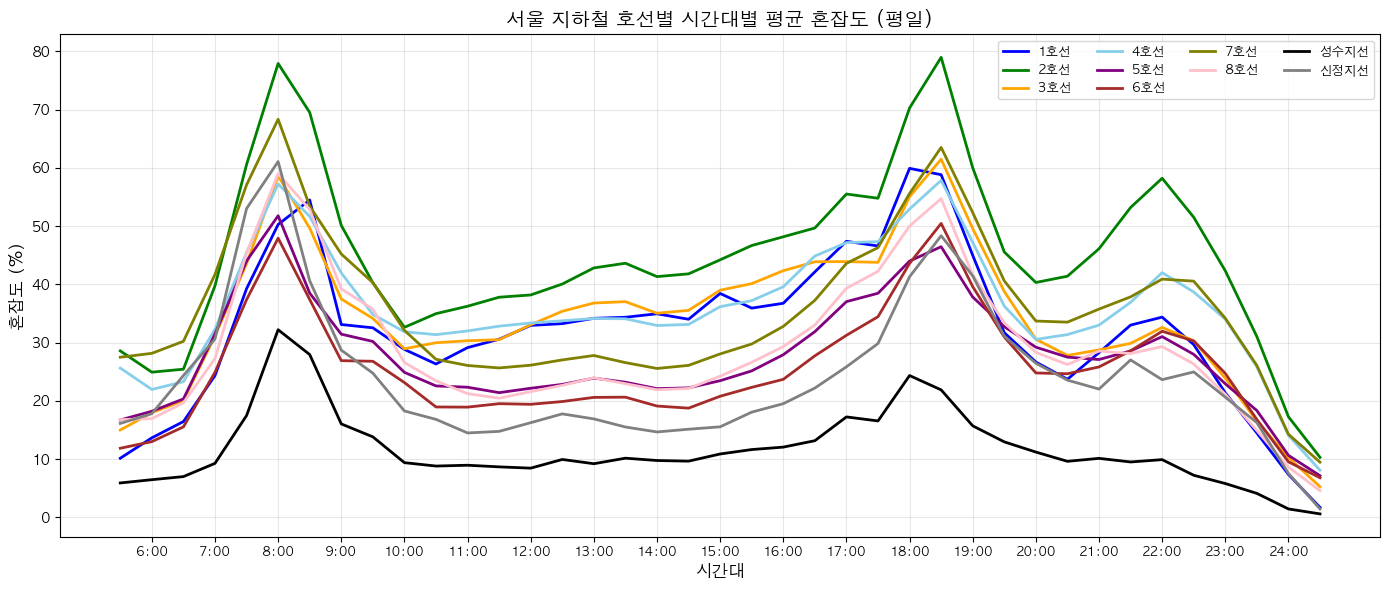

In [7]:
line_avg = df_subway_weekday.groupby('호선')[time_cols].mean()
color_list = ['blue', 'green', 'orange', 'skyblue', 'purple', 'brown', 'olive', 'pink', 'black', 'gray']
colors = { l:c  for l,c in zip(main_lines, color_list) }


fig, ax = plt.subplots(figsize=(14, 6))
for line in main_lines:
    if line in line_avg.index:
        ax.plot(line_avg.loc[line].values, color=colors[line], linewidth=2, label= f'{line}호선' if line.isdecimal() else line)

# x축 라벨: 정각(:00)만 표시 (39개 중 20개만 표시하여 가독성 확보)
labels = [c.replace('~ (%)', '').strip() for c in time_cols]
major_idx = [i for i, l in enumerate(labels) if l.endswith(':00')]
ax.set_xticks(major_idx)
ax.set_xticklabels([labels[i] for i in major_idx], fontsize=9)

ax.set_title('서울 지하철 호선별 시간대별 평균 혼잡도 (평일)', fontsize=14, fontweight='bold')
ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('혼잡도 (%)', fontsize=12)
ax.legend(fontsize=9, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



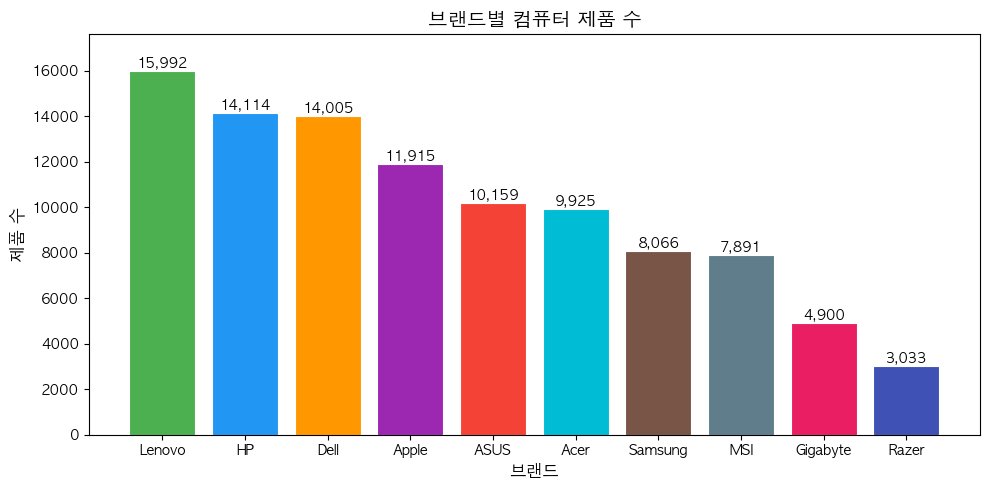

In [8]:
brand_counts = df_comp['brand'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))

color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336',
                     '#00BCD4', '#795548', '#607D8B', '#E91E63', '#3F51B5']

bars = ax.bar(brand_counts.index, brand_counts.values, color=color, edgecolor='white', linewidth=0.8)
# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}',                          # 천 단위 콤마
            ha='center', va='bottom', fontsize=10)
    
ax.set_title('브랜드별 컴퓨터 제품 수', fontsize=14, fontweight='bold')
ax.set_xlabel('브랜드', fontsize=12)
ax.set_ylabel('제품 수', fontsize=12)
ax.set_ylim(0, brand_counts.max() * 1.1)             # y축 여유 공간
plt.tight_layout()
plt.show()

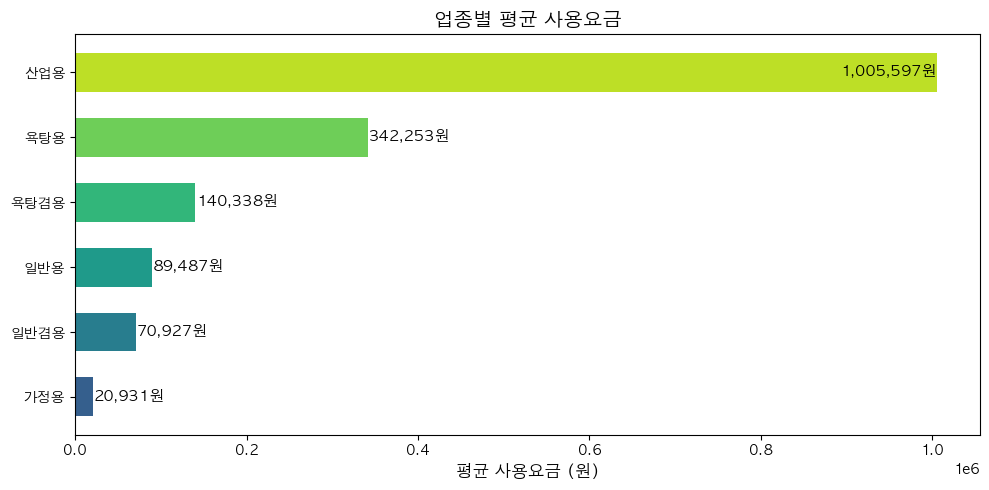

In [9]:
usage_by_type = df_water.groupby('업종')['사용요금'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

# 수평 막대 그래프
bars = ax.barh(usage_by_type.index, usage_by_type.values,
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(usage_by_type))),  # 컬러맵 사용
               height=0.6)

# 막대 끝에 값 표시
for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2.,
            f'{width:,.0f}원', ha='right' if bar.get_width() >=1000000 else 'left', va='center', fontsize=11)

ax.set_title('업종별 평균 사용요금', fontsize=14, fontweight='bold')
ax.set_xlabel('평균 사용요금 (원)', fontsize=12)
plt.tight_layout()
plt.show()

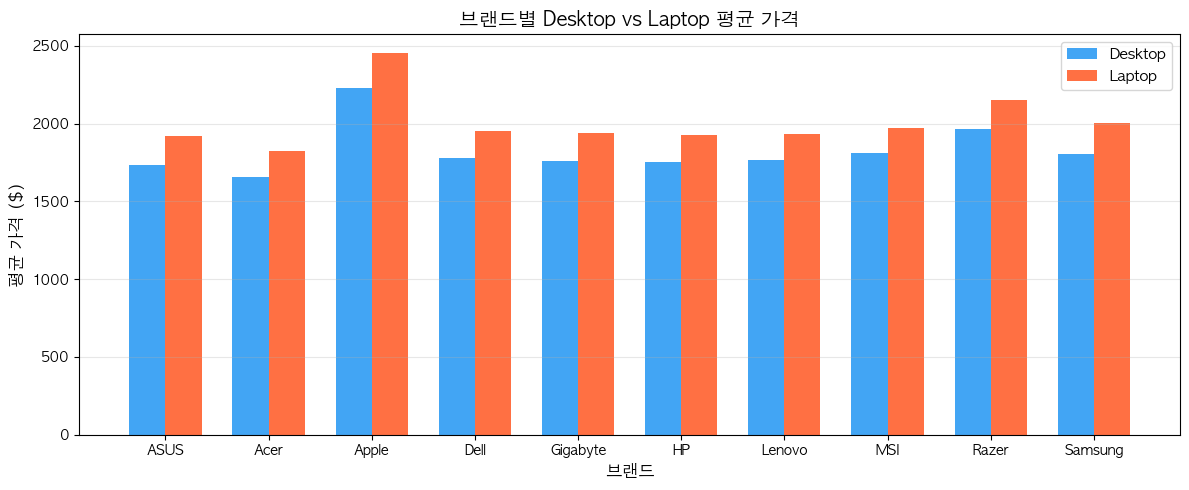

In [10]:
brand_type_price = df_comp.groupby(['brand', 'device_type'])['price'].mean().unstack(fill_value=0)


fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(brand_type_price.index))   # x 위치
width = 0.35                                    # 막대 너비

# 두 그룹의 막대를 나란히 배치
bars1 = ax.bar(x - width/2, brand_type_price['Desktop'], width,
               label='Desktop', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, brand_type_price['Laptop'], width,
               label='Laptop', color='#FF5722', alpha=0.85)

ax.set_title('브랜드별 Desktop vs Laptop 평균 가격', fontsize=14, fontweight='bold')
ax.set_xlabel('브랜드', fontsize=12)
ax.set_ylabel('평균 가격 ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(brand_type_price.index)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

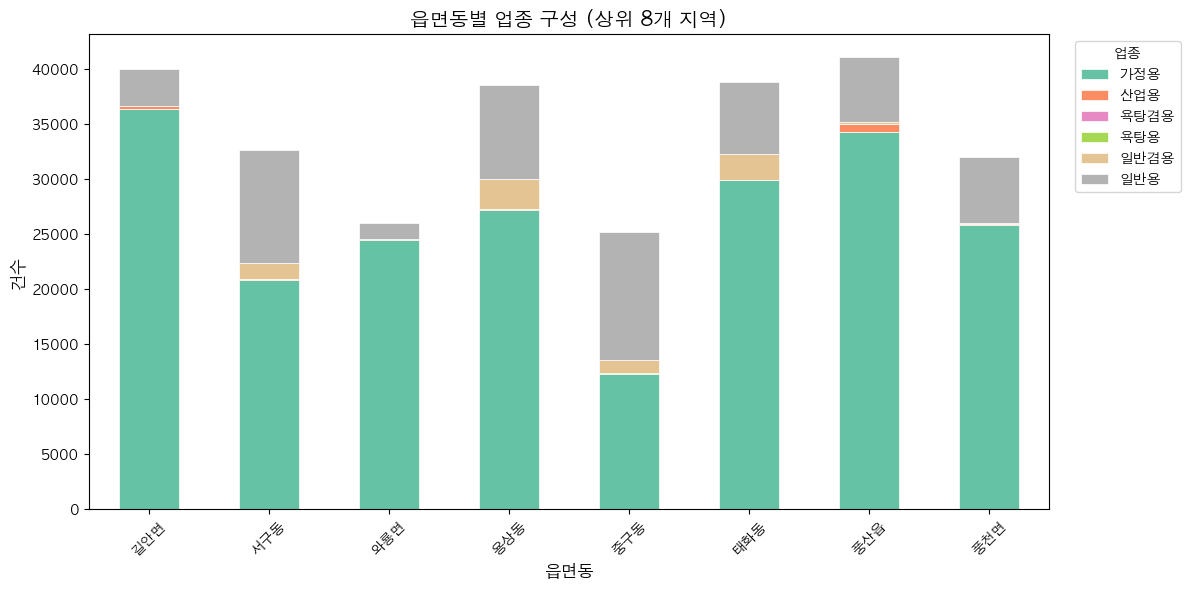

In [11]:
# 누적 막대 그래프 (Stacked Bar Chart)
# 상하수도 데이터: 읍면동별 업종별 건수 구성비

# 데이터 준비 - 상위 8개 읍면동의 업종별 건수
top_dongs = df_water['읍면동명'].value_counts().head(8).index
dong_type = df_water[df_water['읍면동명'].isin(top_dongs)].groupby(
    ['읍면동명', '업종']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# 누적 막대 그래프 (DataFrame의 plot 메서드 활용)
dong_type.plot(kind='bar', stacked=True, ax=ax,
               colormap='Set2', edgecolor='white', linewidth=0.5)

ax.set_title('읍면동별 업종 구성 (상위 8개 지역)', fontsize=14, fontweight='bold')
ax.set_xlabel('읍면동', fontsize=12)
ax.set_ylabel('건수', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title='업종', bbox_to_anchor=(1.02, 1), loc='upper left')  # 범례를 그래프 밖에 배치
plt.tight_layout()
plt.show()

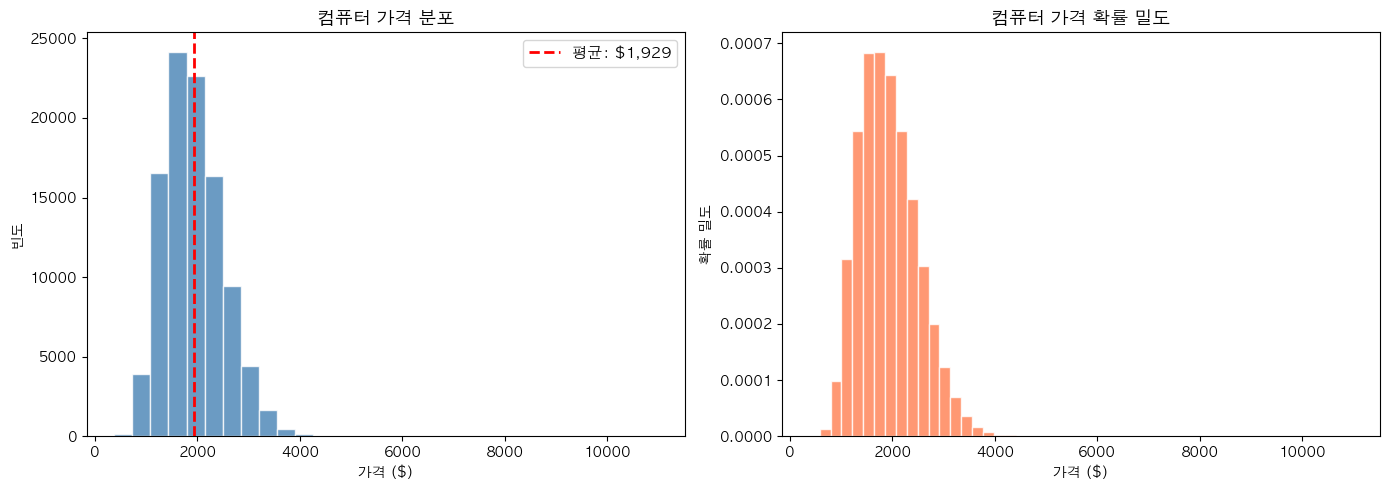

In [12]:
# 기본 히스토그램
# 컴퓨터 데이터: 가격 분포

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 기본 히스토그램
axes[0].hist(df_comp['price'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('컴퓨터 가격 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가격 ($)')
axes[0].set_ylabel('빈도')
axes[0].axvline(df_comp['price'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"평균: ${df_comp['price'].mean():,.0f}")
axes[0].legend(fontsize=11)

# 우측: bins 수 조절 + 밀도(density)
axes[1].hist(df_comp['price'], bins=50, density=True,
             color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('컴퓨터 가격 확률 밀도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가격 ($)')
axes[1].set_ylabel('확률 밀도')

plt.tight_layout()
plt.show()

In [13]:
import seaborn as sns


In [27]:
df_comp_count = df_comp['brand'].value_counts()
print(df_comp_count)


brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64


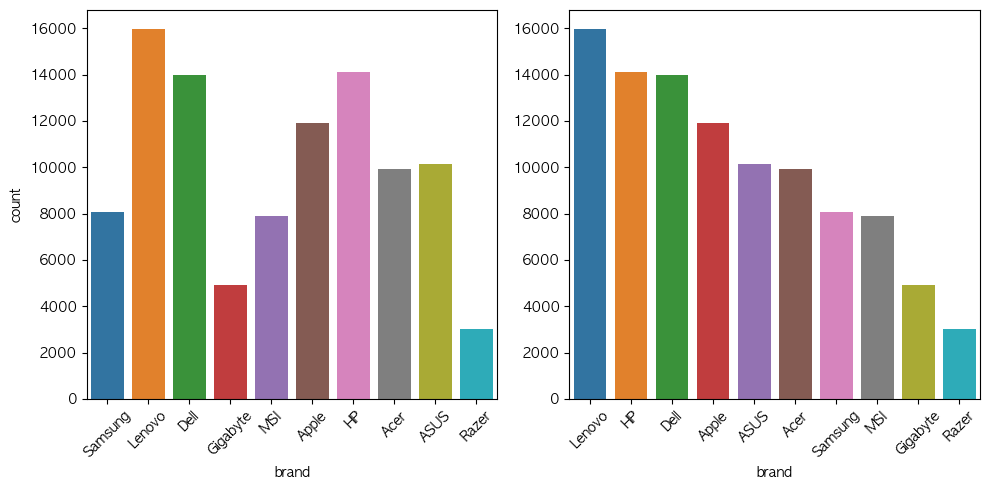

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.countplot(data=df_comp, x='brand', hue='brand', ax=axes[0])
sns.barplot(x=df_comp_count.index, y=df_comp_count.values, hue=df_comp_count.index, ax=axes[1])

axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


<Axes: ylabel='brand'>

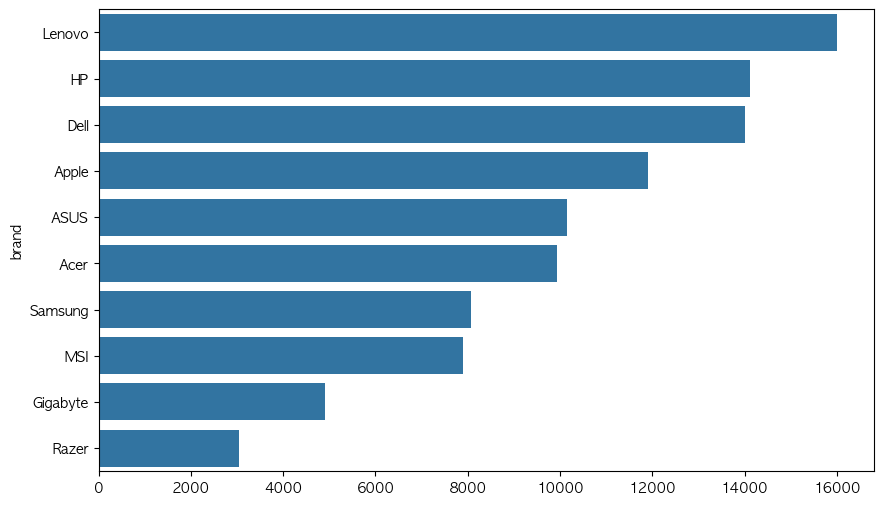

In [34]:
sns.barplot(x=df_comp_count.values, y=df_comp_count.index)


In [54]:
print(df_comp.columns.to_list())

# release_year별 제품개수
df_year_count = df_comp[['release_year', 'device_type']].value_counts().reset_index()
df_year_count

['device_type', 'brand', 'model', 'release_year', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_type', 'storage_gb', 'storage_drive_count', 'display_type', 'display_size_in', 'resolution', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi', 'bluetooth', 'weight_kg', 'warranty_months', 'price']


,release_year,device_type,count
0,2024,Laptop,10838
1,2023,Laptop,10747
2,2022,Laptop,9621
3,2025,Laptop,9488
4,2023,Desktop,7273
5,2021,Laptop,7134
6,2024,Desktop,7131
7,2022,Desktop,6433
8,2025,Desktop,6347
9,2021,Desktop,4882


<Axes: xlabel='release_year', ylabel='count'>

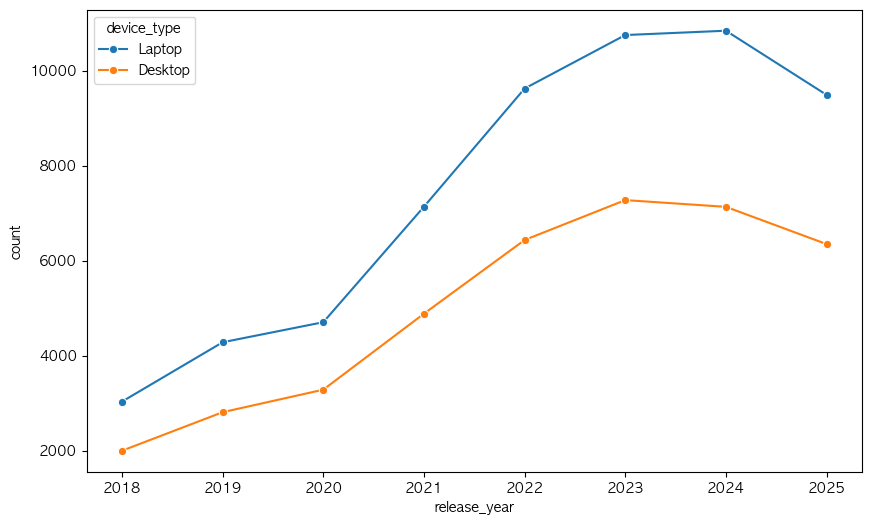

In [58]:
sns.lineplot(data = df_year_count, x='release_year', y='count', hue='device_type', marker='o' )

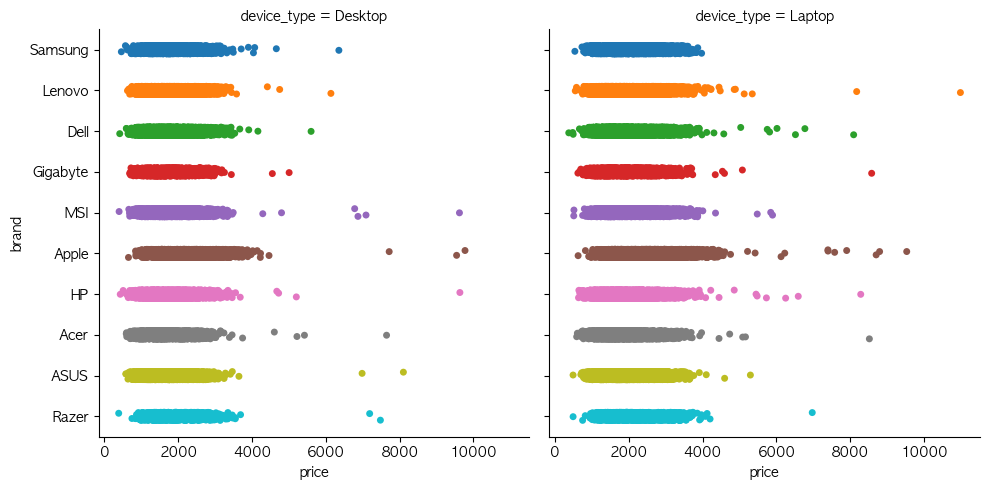

In [61]:
# catplot
sns.catplot(data=df_comp, x='price', y='brand', col='device_type', hue='brand')

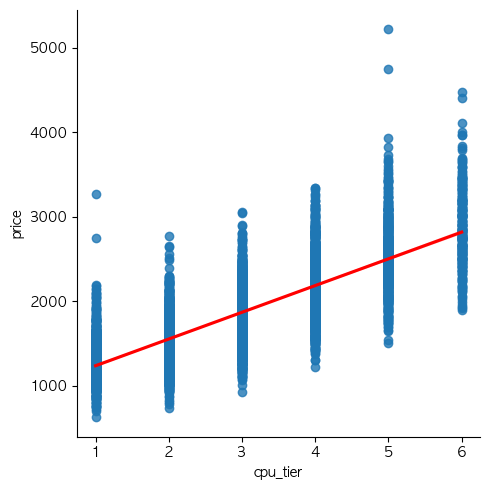

In [71]:
# 범주형 산점도
df_sample = df_comp.sample(5000)
sns.lmplot(data=df_sample, x='cpu_tier', y='price', line_kws={'color':'red'})

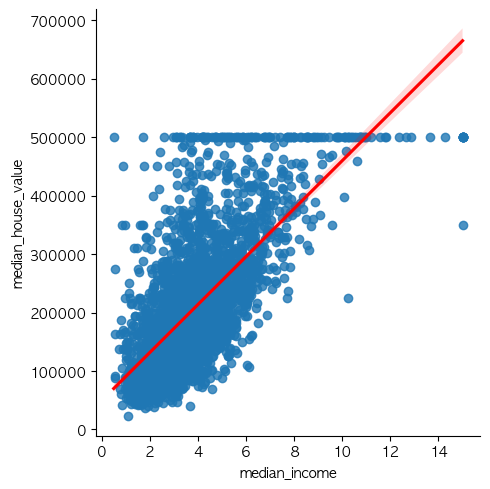

In [67]:
sns.lmplot(data=df_housing, x='median_income', y='median_house_value', line_kws={'color':'red'})


In [69]:
df_comp.corr(numeric_only=True)

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
release_year,1.000000,-0.003788,-0.002468,-0.003357,-0.004120,-0.003345,-0.002626,-0.005210,-0.002416,-0.003399,0.000310,-0.002583,-0.002818,0.001328,-0.000639,-0.001268,0.002489,-0.000905,-0.004031,0.089721
cpu_tier,-0.003788,1.000000,0.937376,0.848197,0.812598,0.780649,0.857225,0.409049,0.899349,0.001006,-0.004603,-0.005014,0.001902,0.006535,0.003966,-0.005501,-0.001991,-0.004079,0.000008,0.759196
cpu_cores,-0.002468,0.937376,1.000000,0.898171,0.784946,0.754672,0.812393,0.380896,0.906770,0.001004,0.016125,0.033156,0.000966,-0.032600,-0.028873,0.032949,-0.000568,0.030376,0.000015,0.720464
cpu_threads,-0.003357,0.848197,0.898171,1.000000,0.711287,0.684021,0.735096,0.556134,0.813155,0.000832,0.014963,0.030767,-0.001144,-0.031301,-0.027150,0.031746,-0.002445,0.029261,0.000063,0.577503
cpu_base_ghz,-0.004120,0.812598,0.784946,0.711287,1.000000,0.960884,0.756057,0.365730,0.761927,-0.001549,0.306749,0.543599,0.002208,-0.551226,-0.463464,0.542196,-0.000556,0.496208,-0.002766,0.529910
cpu_boost_ghz,-0.003345,0.780649,0.754672,0.684021,0.960884,1.000000,0.725862,0.351984,0.731896,-0.002740,0.296044,0.522705,0.003105,-0.530012,-0.445439,0.521395,-0.001981,0.477242,-0.003151,0.508507
gpu_tier,-0.002626,0.857225,0.812393,0.735096,0.756057,0.725862,1.000000,0.498624,0.912918,-0.003123,0.051215,0.091162,0.003855,-0.092325,-0.078105,0.090594,-0.000242,0.083700,-0.002593,0.762875
vram_gb,-0.005210,0.409049,0.380896,0.556134,0.365730,0.351984,0.498624,1.000000,0.441475,0.003355,0.030479,0.050183,-0.001191,-0.052216,-0.044648,0.050708,-0.001494,0.046039,0.001302,0.305017
ram_gb,-0.002416,0.899349,0.906770,0.813155,0.761927,0.731896,0.912918,0.441475,1.000000,-0.001190,0.023607,0.045434,0.001421,-0.045346,-0.039456,0.045059,-0.000578,0.042133,-0.002225,0.758654
storage_gb,-0.003399,0.001006,0.001004,0.000832,-0.001549,-0.002740,-0.003123,0.003355,-0.001190,1.000000,0.001392,-0.003369,0.000212,0.006160,0.002160,-0.004137,0.000408,-0.004279,-0.004392,0.088937


<Axes: xlabel='brand', ylabel='count'>

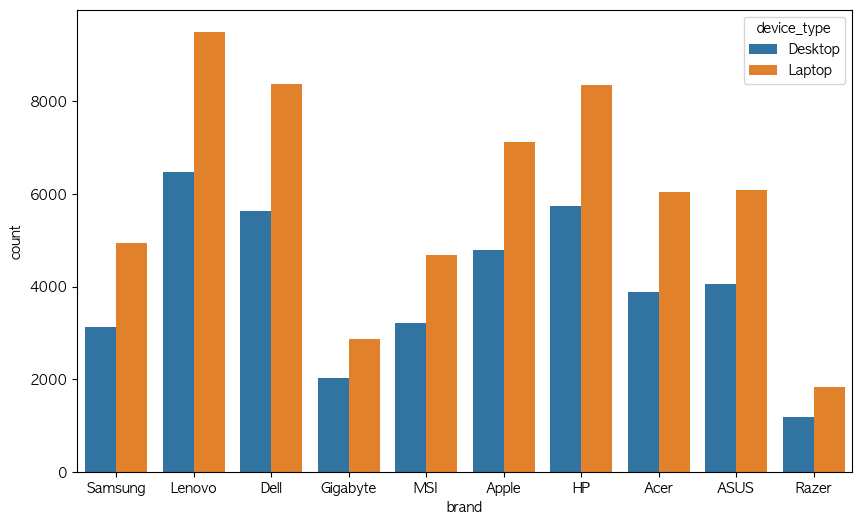

In [73]:
# 빈도수 그래프
sns.countplot(data=df_comp, x='brand', hue='device_type')

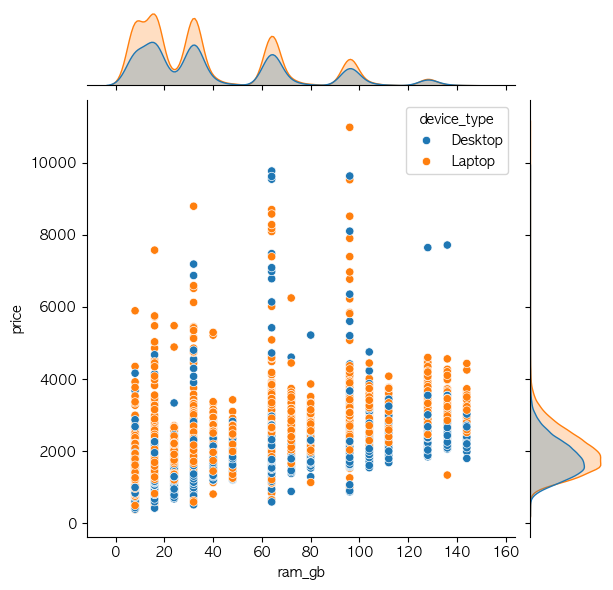

In [76]:
# jointplot
sns.jointplot(data=df_comp, x='ram_gb', y='price', hue='device_type')

      5:30~ (%)  6:00~ (%)  6:30~ (%)  7:00~ (%)  7:30~ (%)  8:00~ (%)  \
호선                                                                       
1     10.160000  13.660000  16.455000  24.340000  39.250000  50.270000   
2     28.581395  24.929070  25.438372  39.755814  60.546512  77.896512   
3     15.002941  17.973529  20.052941  31.136765  43.526471  58.611765   
4     25.636538  21.963462  23.286538  32.290385  45.434615  57.228846   
5     16.725243  18.221359  20.335922  31.492233  44.002913  51.772816   
6     11.873239  13.011268  15.538028  24.911268  37.374648  47.925352   
7     27.492157  28.161765  30.224510  41.695098  57.065686  68.323529   
8     16.785294  16.952941  19.664706  27.258824  45.361765  58.991176   
성수지선   5.920000   6.480000   7.010000   9.280000  17.480000  32.210000   
신정지선  16.130000  17.810000  24.350000  30.620000  53.000000  61.070000   

      8:30~ (%)  9:00~ (%)  9:30~ (%)  10:00~ (%)  ...  20:00~ (%)  \
호선                                       

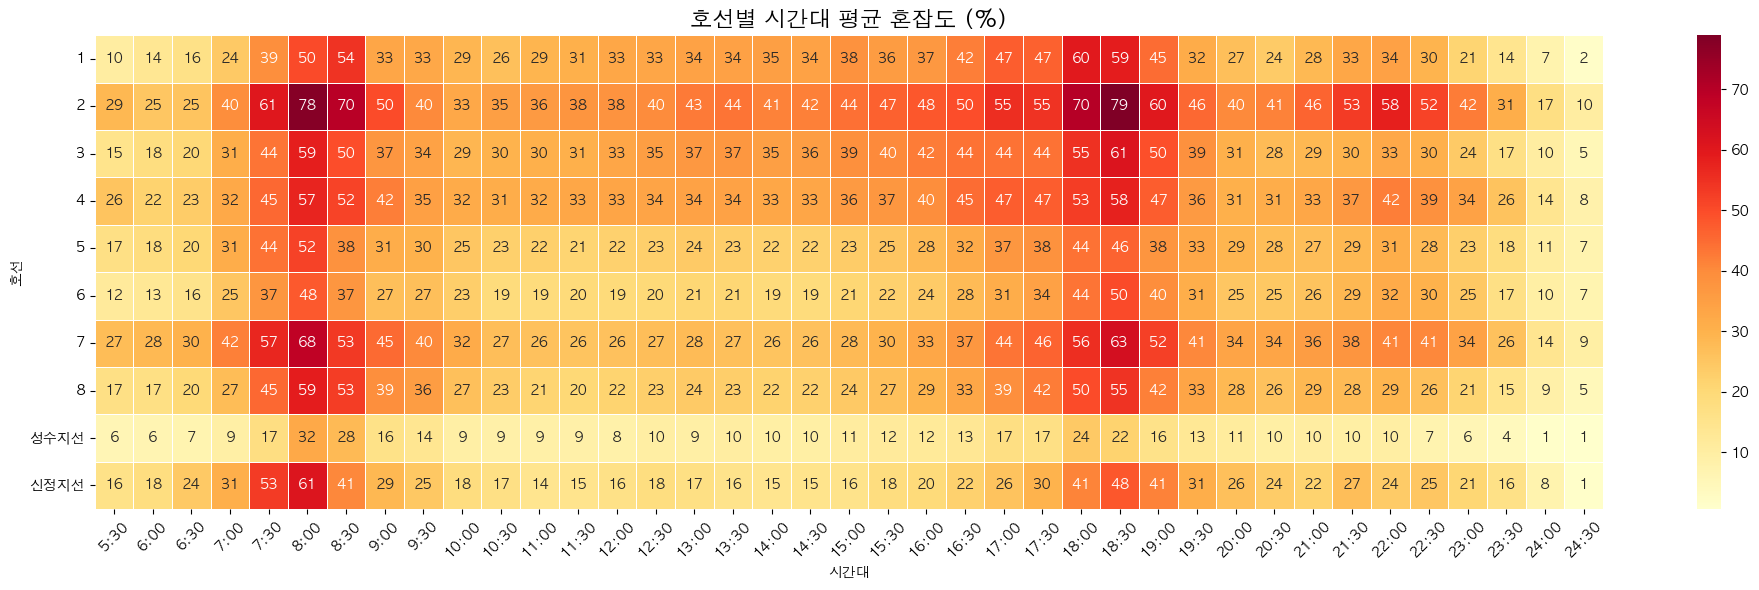

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('pandas/data/서울교통공사_ 혼잡도_20171231.csv', encoding='cp949')

# 시간대 컬럼만 추출 (5:30~ ~ 24:30~)
time_cols = [col for col in df.columns if '~' in col]

# 호선별 시간대 평균 혼잡도 계산
# 평일 데이터만 필터링
df = df[df['요일'] == '평일']
heatmap_data = df.groupby('호선')[time_cols].mean()
print(heatmap_data)

# 컬럼명 간소화 (예: "8:00~ (%)" → "8:00")
heatmap_data.columns = [col.replace('~ (%)', '') for col in heatmap_data.columns]

# 히트맵 그리기
plt.figure(figsize=(20, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('호선별 시간대 평균 혼잡도 (%)', fontsize=16)
plt.xlabel('시간대')
plt.ylabel('호선')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


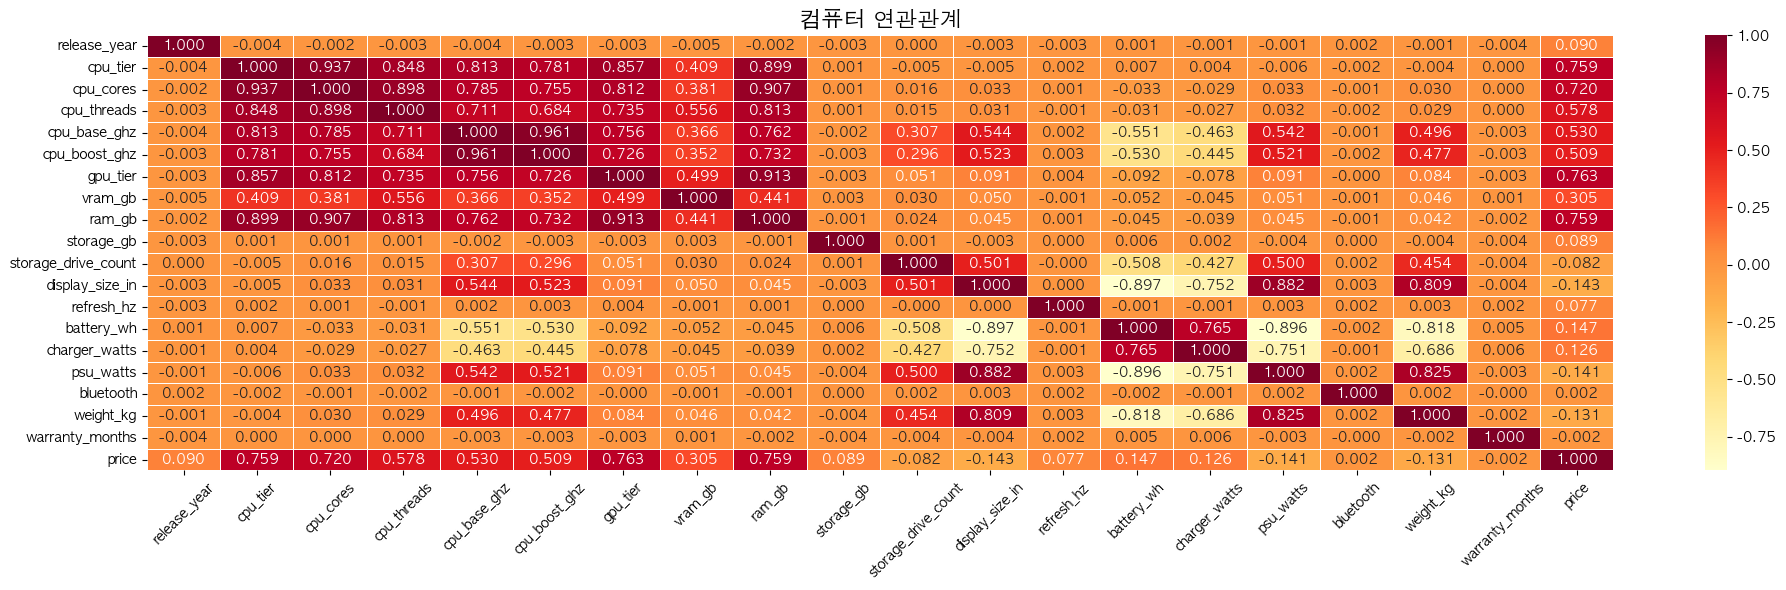

In [81]:
# 히트맵 그리기
plt.figure(figsize=(20, 6))
sns.heatmap(df_comp.corr(numeric_only=True), annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('컴퓨터 연관관계', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

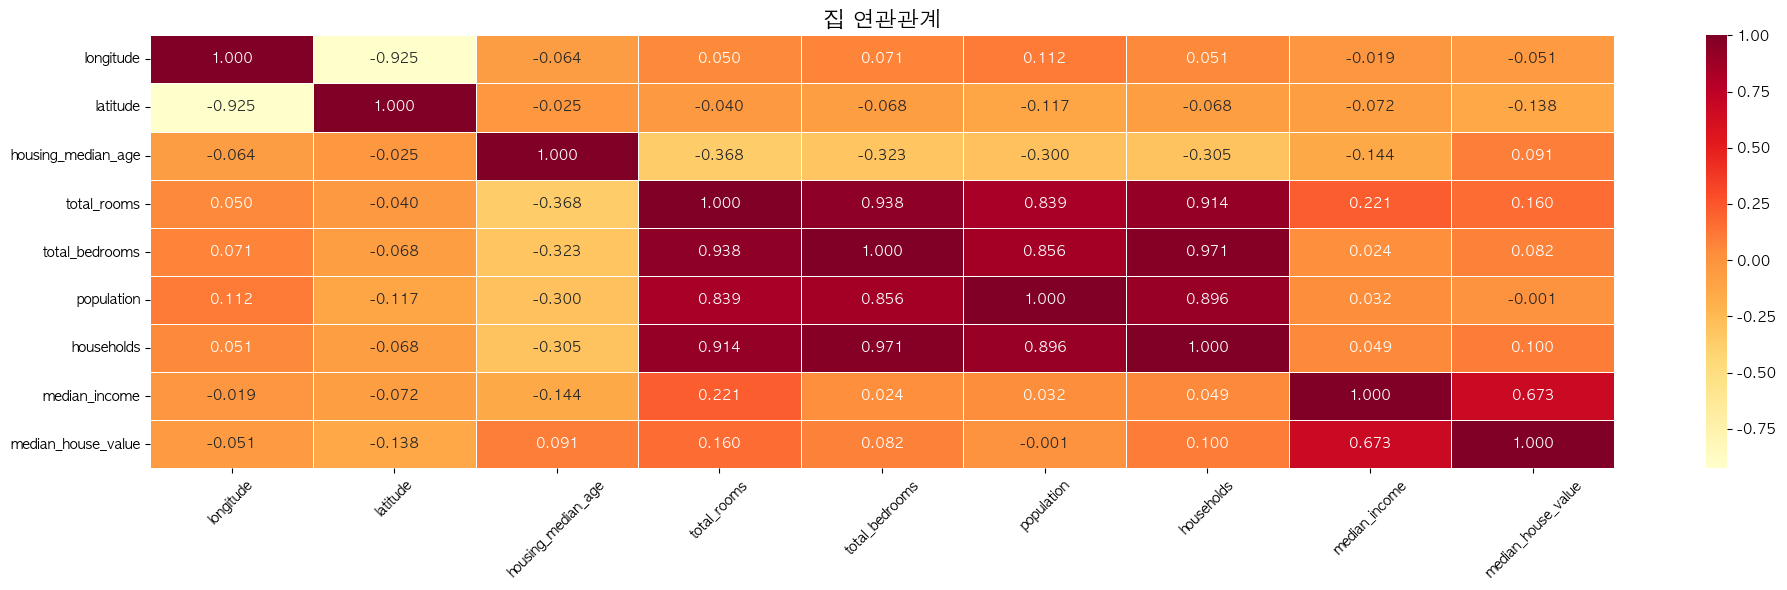

In [82]:
# 히트맵 그리기
plt.figure(figsize=(20, 6))
sns.heatmap(df_housing.corr(numeric_only=True), annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('집 연관관계', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

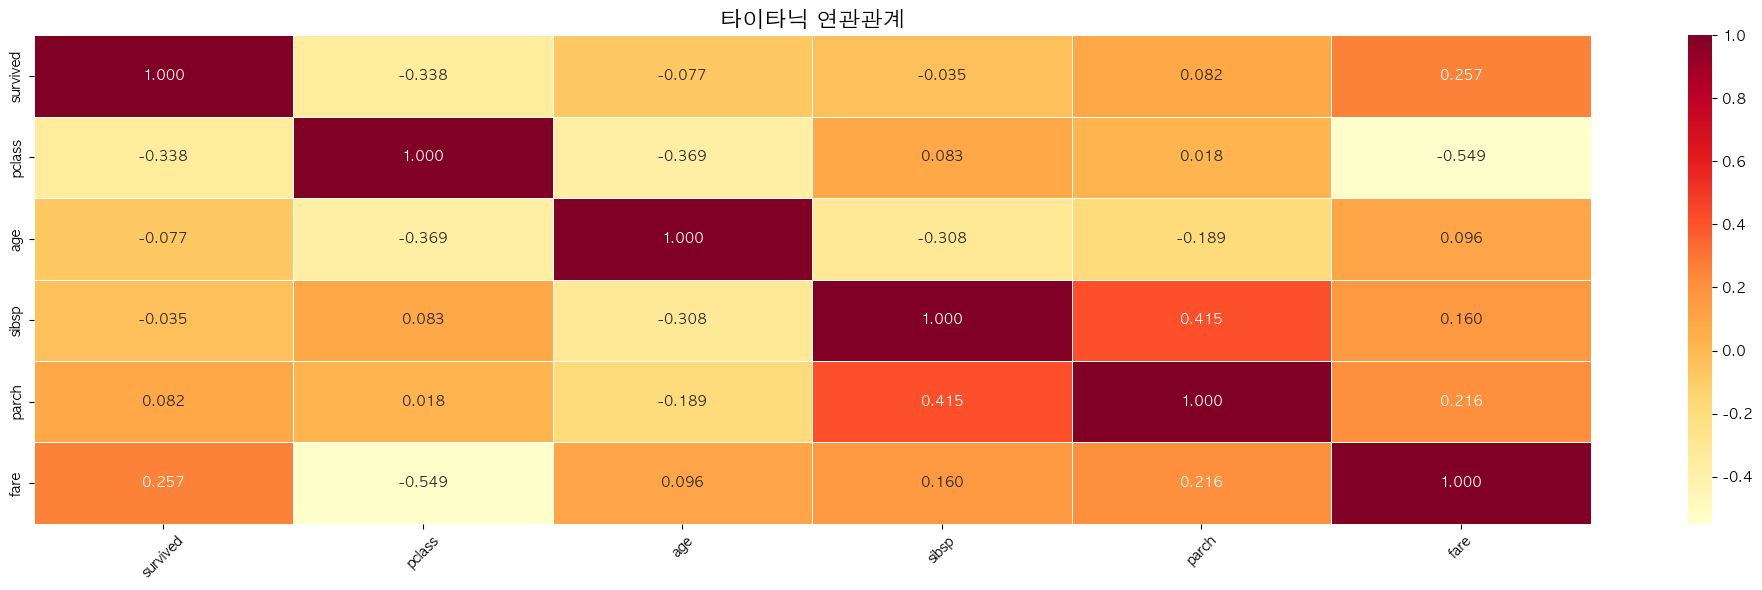

In [83]:
# 히트맵 그리기
plt.figure(figsize=(20, 6))
sns.heatmap(df_titanic.corr(numeric_only=True), annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('타이타닉 연관관계', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

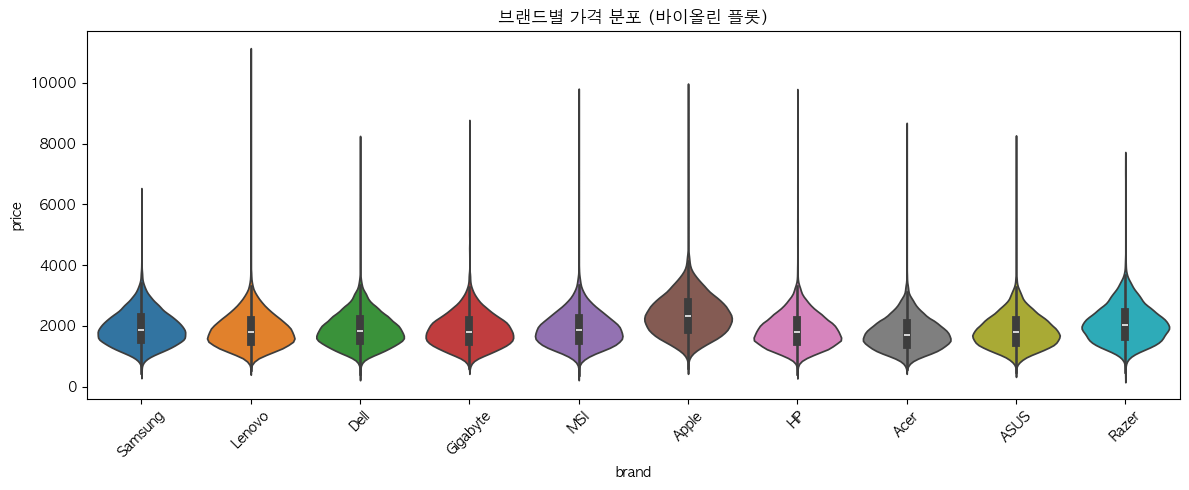

In [84]:
# === 바이올린 그래프 (Violin Plot) ===
# 박스플롯 + 분포(밀도) 모양을 동시에 보여주는 그래프
# 데이터가 어디에 밀집해 있는지 "두께"로 표현됨

# 예제 1: 브랜드별 가격 분포
plt.figure(figsize=(12, 5))
sns.violinplot(data=df_comp, x='brand', y='price', hue='brand')
plt.title('브랜드별 가격 분포 (바이올린 플롯)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

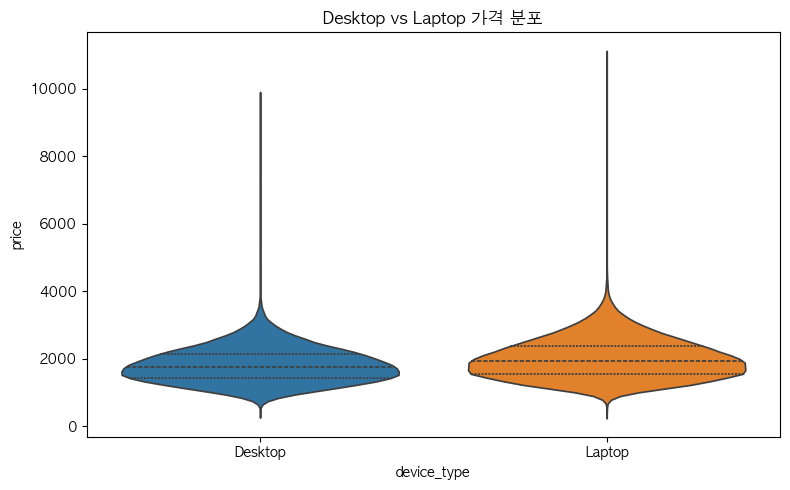

In [85]:
# 예제 2: 디바이스 타입별 가격 분포 (Desktop vs Laptop)
# inner='quartile' → 안에 사분위수(25%, 50%, 75%) 점선 표시
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_comp, x='device_type', y='price', 
               hue='device_type', inner='quartile')
plt.title('Desktop vs Laptop 가격 분포')
plt.tight_layout()
plt.show()

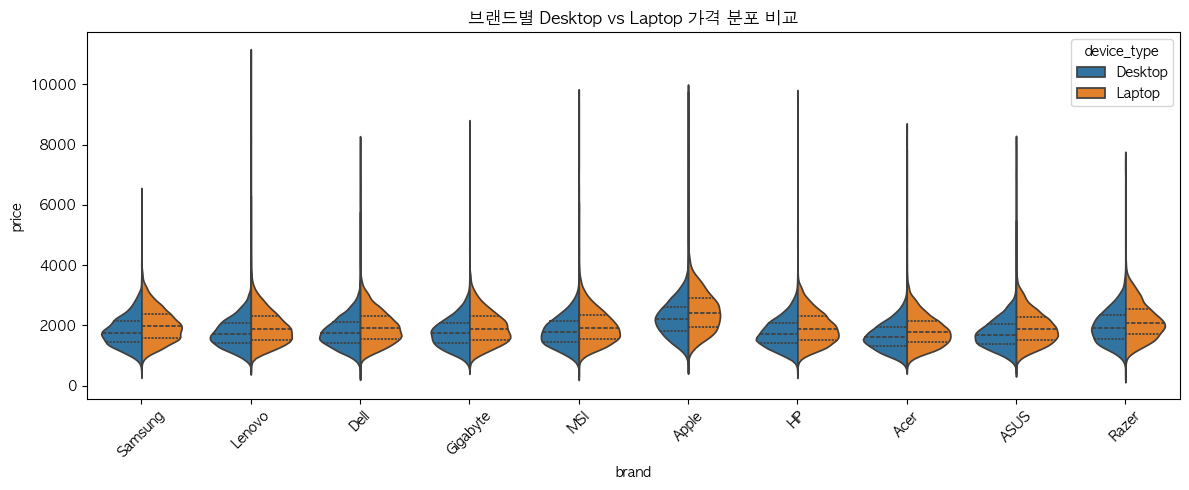

In [86]:
# 예제 3: 브랜드별 + 디바이스 타입별 비교 (split=True)
# split=True → 좌우로 나눠서 두 그룹을 한 바이올린 안에서 비교
plt.figure(figsize=(12, 5))
sns.violinplot(data=df_comp, x='brand', y='price', 
               hue='device_type', split=True, inner='quartile')
plt.title('브랜드별 Desktop vs Laptop 가격 분포 비교')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()